In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import functools
from math import pi

import numpy as np
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.collision_heatmap import bin2d_maximum, make_colorbar, mycmap


plt.style.use("fluxoniumcr.plotting.paper")

In [3]:
parent_path = (
    DATA_DIR
    /"control_target_collision"
    / f"EJ=4.00,EC=1.20,EL=0.40,deltap=0.8"
)
dataset = xr.load_dataset(parent_path/"01to02_harmonic=-3.hdf5")

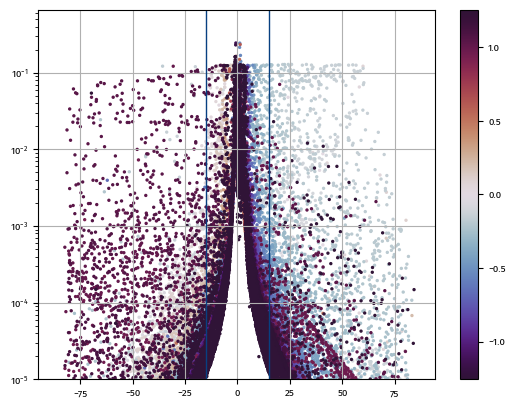

In [4]:
fig, ax = plt.subplots()


ds = dataset.isel(JC=1)
leakage = ds.transition_probability.sel(target_bra=2).sum('control_bra').mean(['control_ket', 'target_ket'])

z = ds.drive_frequency - 1.332*2*pi
idx = np.argsort(abs(z))
z = z.sel(index=idx)

s = ax.scatter(
    ds.delta_frequency.sel(index=idx) / (2*pi) * 1e3,
    leakage.sel(index=idx),
    s=2,
    c=z,
    cmap='twilight_shifted',
    vmin=-0.2 * 2*pi,
    vmax=0.2 * 2*pi,
)
ax.set_yscale('log')
ax.set_ylim(1e-5)
plt.colorbar(s)

plt.axvline(-15)
plt.axvline(+15)

plt.grid()

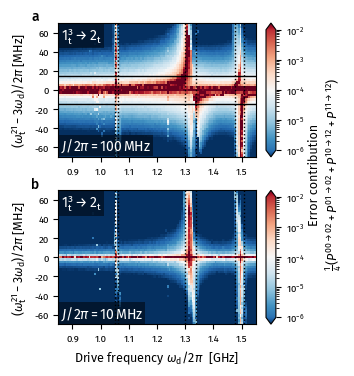

In [11]:
fig = plt.figure(
    figsize=(85/25.4, 90/25.4),
)

gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[100, 5],
    hspace=0.25,
    wspace=0.1,
)

ax1 = fig.add_subplot(gs[0, 0])
cax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1, sharey=ax1)
cax2 = fig.add_subplot(gs[1, 1])

# ax1.tick_params(labelbottom=False)

hm_x = np.linspace(0.8, 1.6, 128) * 2*pi
hm_y = np.linspace(-80e-3, 80e-3, 64) * 2*pi

z1 = 1/4 * sum(
    dataset.isel(JC=1).transition_probability.sel(
        control_bra=i,
        control_ket=i,
        target_bra=2,
        target_ket=j,
    )
    for i in range(2)
    for j in range(2)
).data

z2 = 1/4 * sum(
    dataset.isel(JC=0).transition_probability.sel(
        control_bra=i,
        control_ket=i,
        target_bra=2,
        target_ket=j,
    )
    for i in range(2)
    for j in range(2)
).data

hm1 = bin2d_maximum(
    dataset.drive_frequency.data,
    dataset.delta_frequency.data,
    z1,
    hm_x,
    hm_y,
)

hm2 = bin2d_maximum(
    dataset.drive_frequency.data,
    dataset.delta_frequency.data,
    z2,
    hm_x,
    hm_y,
)

norm = mpl.colors.LogNorm(vmin=1e-6/5, vmax=5e-2)
    
ax1.pcolormesh(
    hm_x,
    hm_y,
    hm1,
    rasterized=True,
    cmap=mycmap,
    norm=norm,
)

ax2.pcolormesh(
    hm_x,
    hm_y,
    hm2,
    rasterized=True,
    cmap=mycmap,
    norm=norm,
)

for cax in (cax1, cax2):
    make_colorbar(
        cax,
        norm=norm,
        cmap=mycmap,
        vmin=1e-6,
        vmax=1e-2,
        yticks=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
#         label="Error contribution",
#         label=r"$\frac{1}{4}(P^{00\to02} + P^{01\to02} + P^{10\to12} + P^{11\to12})$",
    )

ax1.set_xlim(0.85 * 2*pi, 1.55 * 2*pi)
ax1.set_ylim(-70e-3 * 2*pi, 70e-3 * 2*pi)

ax1.xaxis.set_major_formatter(lambda x, pos: f"{x/(2*pi):.1f}")
ax1.yaxis.set_major_formatter(lambda x, pos: f"{x*1e3/(2*pi):.0f}")
ax1.set_xticks(np.array([0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]) * 2*pi)
ax1.set_yticks(np.array([-60, -40, -20, 0.0, 20, 40, 60]) * 1e-3 *2*pi)

# for ax in [ax1, ax2]:
for ax in [ax2]:
    ax.set_xlabel(r"Drive frequency $\omega_\mathrm{d}/2\pi$  [GHz]")

ax1.set_ylabel(r"$(\omega_\mathrm{t}^{21} - 3\omega_\mathrm{d})/2\pi$" + " [MHz]")
ax2.set_ylabel(r"$(\omega_\mathrm{t}^{21} - 3\omega_\mathrm{d})/2\pi$" + " [MHz]")


for sign in (1, -1):
    ax1.plot(
        np.array([0.8, 1.262, 1.262, 1.362, 1.362, 1.6]) * (2*pi),
#         sign * np.array([15, 15, 50, 50, 15, 15]) * (1e-3 * 2*pi),
        sign * np.array([15, 15, 15, 15, 15, 15]) * (1e-3 * 2*pi),
        c='black',
        solid_joinstyle='miter',
    )
    
for ax in [ax1, ax2]:
    c = 'black'
    ax.axvline(1.299 * (2*pi), ls=':', c=c)
    ax.axvline(1.337 * (2*pi), ls=':', c=c)
    ax.axvline(1.050 * (2*pi), ls=':', c=c)
    ax.axvline(1.062 * (2*pi), ls=':', c=c)
    ax.axvline(1.478 * (2*pi), ls=':', c=c)
    ax.axvline(1.510 * (2*pi), ls=':', c=c)

for ax, label in [(ax1, "a"), (ax2, "b")]:
    annotation = ax.annotate(
        label,
        (0.00, 1.00),
#         (-26, 4),
        (-14, 10),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="right",
        va="top",
        zorder=1,
    )

for ax, num in [(ax1, 100), (ax2, 10)]:
    annotation = ax.annotate(
        r"$J/2\pi=" + str(num) + r"\,\mathrm{MHz}$",
        (0.00, 0.00),
        (1.8, 1.8),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="left",
        va="bottom",
        c='white',
        zorder=2,
        bbox=dict(boxstyle='square,pad=0.15', fc='black', ec='none', alpha=0.5),
    )
    
for ax, label in [
        (ax1, r"$1_\mathrm{t}^3\to2_\mathrm{t}$"),
        (ax2, r"$1_\mathrm{t}^3\to2_\mathrm{t}$"),
]:
    annotation = ax.annotate(
        label,
        (0.00, 1.00),
        (1.8, -1.8),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="left",
        va="top",
        c='white',
        zorder=2,
        bbox=dict(boxstyle='square,pad=0.15', fc='black', ec='none', alpha=0.5)
    )


fig.subplots_adjust(
    left=0.15,
    right=0.80,
    bottom=0.11,
    top=0.96,
)

fig.supylabel(
    "Error contribution\n"r"$\frac{1}{4}(P^{00\to02} + P^{01\to02} + P^{10\to12} + P^{11\to12})$",
    x=0.95,
    y=(0.11+0.96)/2,
    ha='center'
)

fig.savefig("control_target_third_harmonic.pdf")

(np.float64(1.823779594750543e-10), np.float64(0.665226227595677))

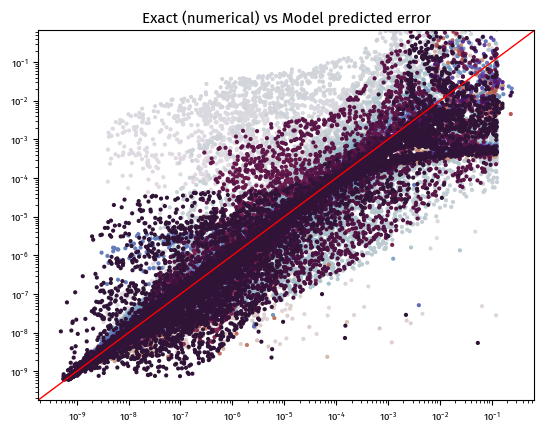

In [10]:
fig, ax = plt.subplots()

plt.title("Exact (numerical) vs Model predicted error")

ds = dataset.isel(JC=1)
leakage = ds.transition_probability.sel(target_bra=2).sum('control_bra').mean(['control_ket', 'target_ket'])

z = ds.drive_frequency - 1.332*2*pi
idx = np.argsort(abs(z))
z = z.sel(index=idx)

ax.scatter(
    leakage.sel(index=idx),
    ds.model_error.sel(index=idx),
    s=4,
    c=z,
    cmap='twilight_shifted',
    vmin=-0.2 * 2*pi,
    vmax=0.2 * 2*pi,
)

ax.set_xscale('log')
ax.set_yscale('log')

xlim = ax.get_xlim()
ylim = ax.get_ylim()
plt.plot(xlim, xlim, c='red')
ax.set_xlim(xlim)
ax.set_ylim(xlim)